In [1]:
import numpy as np
import gudhi as gd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from scipy.spatial import distance_matrix

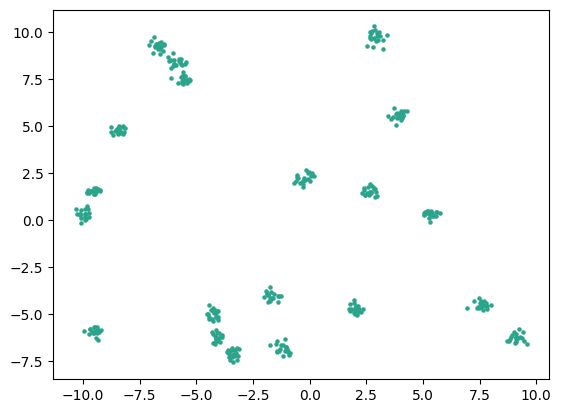

In [2]:
#Ejemplo de Datos
Datos,y=make_blobs(n_samples=400, centers=20, n_features=2, random_state=5, cluster_std=0.2)
X=Datos
#Hasta cuantos clusters aplicar el método
max_k=60

plt.figure()
plt.scatter(Datos[:,0], Datos[:,1], s=5, color='#2AA58B')
plt.show()

# **Comparación con Complejos Testigos**

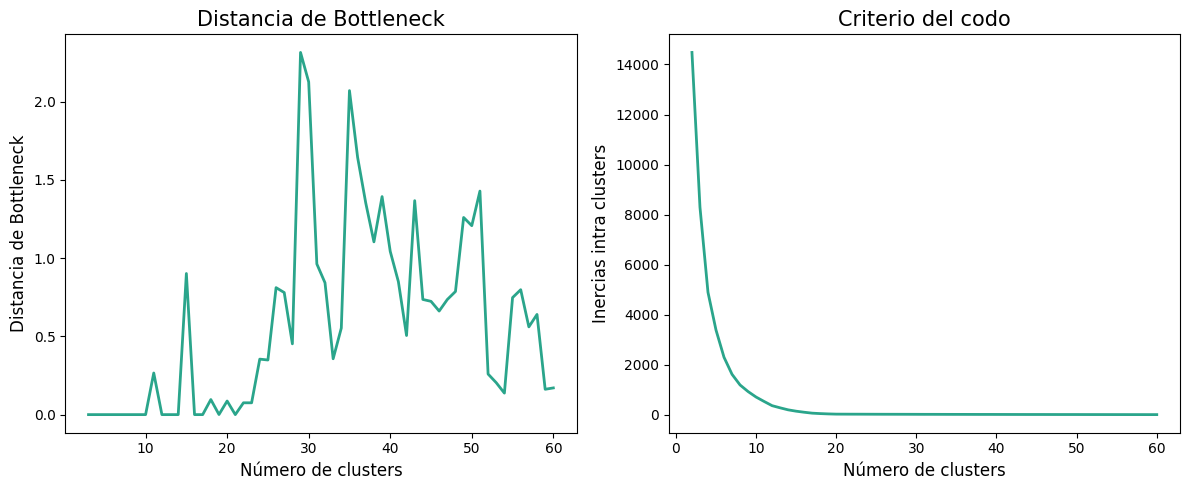

In [3]:
inercias = []
bottleneck_dists = []
prev_diag = None
for k in range(2, max_k+1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    landmarks = kmeans.cluster_centers_
    inercias.append(kmeans.inertia_)
        
    dist_matrix = distance_matrix(landmarks, Datos)
    gudhi_table = []
    for t in range(dist_matrix.shape[1]):
        distances_to_witness = dist_matrix[:, t]
            
        witness_entries = [
            (idx, dist) for idx, dist in enumerate(distances_to_witness)
        ]

        witness_entries.sort(key=lambda x: x[1])
        gudhi_table.append(witness_entries)
        
    Wt = gd.WitnessComplex(nearest_landmark_table=gudhi_table)
    simplex_tree = Wt.create_simplex_tree(max_alpha_square=200, limit_dimension=1)
    diag = simplex_tree.persistence()
    aux = simplex_tree.persistence_intervals_in_dimension(0) 
        
    if prev_diag is not None:
        dist_b = gd.bottleneck_distance(prev_diag, aux)
        bottleneck_dists.append(dist_b)
        
    prev_diag = aux
        
plt.figure(figsize=(12, 5)) 

plt.subplot(1,2,1)
plt.plot(list(range(3, max_k+1)), bottleneck_dists, color='#2AA58B', linewidth=2)
plt.title(f'Distancia de Bottleneck', fontsize=15)  
plt.xlabel('Número de clusters', fontsize=12)
plt.ylabel('Distancia de Bottleneck', fontsize=12) 
    
plt.subplot(1,2,2)
plt.plot(list(range(2, max_k+1)), inercias, color='#2AA58B', linewidth=2)
plt.title(f'Criterio del codo', fontsize=15)
plt.xlabel('Número de clusters', fontsize=12)
plt.ylabel('Inercias intra clusters', fontsize=12)
    
plt.tight_layout()  
plt.show()

# **Comparación con Complejos de Vietoris-Rips**

In [ ]:
inercias = []
bottleneck_dists = []

VR=gd.RipsComplex(points=X)
alpha_simplex_tree = VR.create_simplex_tree()
diag_alpha = alpha_simplex_tree.persistence()
dim0_alpha = alpha_simplex_tree.persistence_intervals_in_dimension(0)
    
for k in range(2, max_k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    landmarks = kmeans.cluster_centers_
    inercias.append(kmeans.inertia_)
        
    dist_matrix = distance_matrix(landmarks, X)
    gudhi_table = []
    for t in range(dist_matrix.shape[1]):
        distances_to_witness = dist_matrix[:, t]
            
        witness_entries = [
            (idx, dist) for idx, dist in enumerate(distances_to_witness)
        ]

        witness_entries.sort(key=lambda x: x[1])
        gudhi_table.append(witness_entries)

    Wt = gd.WitnessComplex(nearest_landmark_table=gudhi_table)
    simplex_tree = Wt.create_simplex_tree(limit_dimension=1)
            
    diag = simplex_tree.persistence()
    aux = simplex_tree.persistence_intervals_in_dimension(0) 
            
    dist_b = gd.bottleneck_distance(dim0_alpha, aux)
    bottleneck_dists.append(dist_b)
        
plt.figure(figsize=(12, 5))  

plt.subplot(1,2,1)
plt.plot(list(range(2, max_k)), bottleneck_dists, color='#2AA58B', linewidth=2)
plt.title(f'Distancia de Bottleneck con Vietoris-Rips', fontsize=15)  
plt.xlabel('Número de clusters', fontsize=12)
plt.ylabel('Distancia de Bottleneck', fontsize=12) 
    
plt.subplot(1,2,2)
plt.plot(list(range(2, max_k)), inercias, color='#2AA58B', linewidth=2)
plt.title(f'Criterio del codo', fontsize=15)
plt.xlabel('Número de clusters', fontsize=12)
plt.ylabel('Inercias intra clusters', fontsize=12)
    
plt.tight_layout()  
plt.show()

# **Comparación con Complejos Alpha**

In [ ]:
inercias = []
bottleneck_dists = []

AC=gd.AlphaComplex(X)
alpha_simplex_tree = AC.create_simplex_tree()
diag_alpha = alpha_simplex_tree.persistence()
dim0_alpha = alpha_simplex_tree.persistence_intervals_in_dimension(0)
    
for k in range(2, max_k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    landmarks = kmeans.cluster_centers_
    inercias.append(kmeans.inertia_)
        
    dist_matrix = distance_matrix(landmarks, X)
    gudhi_table = []
    for t in range(dist_matrix.shape[1]):
        distances_to_witness = dist_matrix[:, t]
            
        witness_entries = [
            (idx, dist) for idx, dist in enumerate(distances_to_witness)
        ]

        witness_entries.sort(key=lambda x: x[1])
        gudhi_table.append(witness_entries)

    Wt = gd.WitnessComplex(nearest_landmark_table=gudhi_table)
    simplex_tree = Wt.create_simplex_tree(limit_dimension=1)
            
    diag = simplex_tree.persistence()
    aux = simplex_tree.persistence_intervals_in_dimension(0) 
            
    dist_b = gd.bottleneck_distance(dim0_alpha, aux)
    bottleneck_dists.append(dist_b)
        
plt.figure(figsize=(12, 5))  

plt.subplot(1,2,1)
plt.plot(list(range(2, max_k)), bottleneck_dists, color='#2AA58B', linewidth=2)
plt.title(f'Distancia de Bottleneck con Alpha', fontsize=15)  
plt.xlabel('Número de clusters', fontsize=12)
plt.ylabel('Distancia de Bottleneck', fontsize=12) 
    
plt.subplot(1,2,2)
plt.plot(list(range(2, max_k)), inercias, color='#2AA58B', linewidth=2)
plt.title(f'Criterio del codo', fontsize=15)
plt.xlabel('Número de clusters', fontsize=12)
plt.ylabel('Inercias intra clusters', fontsize=12)
    
plt.tight_layout()  
plt.show()